In [1]:
import numpy as np
import pandas as pd

import scarf
from scarf.plotting import CellField, ColorScale

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Reuse the saved run and its frozen cell selection.
analysis_run = ds.pipeline.open(label="docs_default")
# Keep the graph used by the saved analysis.
graph = analysis_run["connectivity_map"]
# Inspect the opened assays and their dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

In [3]:
# Read the published cell-type labels for the selected cells.
annotations = ds.cells.fetch("clusters", key="I")
# Mark ductal cells as the source population.
source = annotations == "Ductal"
# Mark the pooled terminal populations.
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
# Require at least one annotated source cell and one sink cell.
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
# Start every graph cell with zero source or sink mass.
source_sink_vector = np.zeros(len(annotations), dtype=float)
# Share total mass -1 among the source cells.
source_sink_vector[source] = -1.0 / source.sum()
# Share total mass +1 among the pooled sink cells.
source_sink_vector[sink] = 1.0 / sink.sum()
# Orient the graph using the chosen source and sinks.
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
# Check the number of cells used to orient the graph.
pd.Series({"source cells": int(source.sum()), "sink cells": int(sink.sum())})

source cells     916
sink cells      1142
dtype: int64

In [4]:
# Keep the computed clustering used to define terminal boundaries.
sink_labels_ref = analysis_run["clusters"]
# Read its labels in the run's cell order.
sink_labels = analysis_run.cells.fetch("clusters")
# Check that imported and computed labels cover the same cell count.
assert len(annotations) == len(sink_labels)
# Measure each published annotation's share within each cluster.
shares = pd.crosstab(
    sink_labels,
    annotations,
    rownames=["cluster"],
    colnames=["annotation"],
    normalize="index",
)
# Show the majority annotation and its share for every cluster.
sink_table = pd.DataFrame(
    {"annotation": shares.idxmax(axis=1), "majority share": shares.max(axis=1)}
)
# Inspect every candidate cluster before choosing terminal boundaries.
sink_table

,annotation,majority share
cluster,,
1,Pre-endocrine,0.844687
2,Ductal,0.771484
3,Alpha,0.928416
4,Ductal,0.961864
5,Pre-endocrine,0.616046
6,Epsilon,0.678392
7,Ductal,0.827586
8,Ductal,0.684685
9,Ngn3 high EP,1.000000


In [5]:
# Choose the three candidate terminal identities.
candidate_fates = ["Alpha", "Beta", "Delta"]
# Keep one cluster for each requested terminal identity.
selected = sink_table.loc[sink_table["annotation"].isin(candidate_fates)]
# Count the candidate fates before checking for missing or duplicated matches.
n_fates = len(candidate_fates)
# Check that each requested fate identifies exactly one cluster.
valid_fates = len(selected) == n_fates == selected["annotation"].nunique()
# Reject a missing or ambiguous terminal-cluster choice.
if not valid_fates:
    raise ValueError("Each candidate fate must match exactly one cluster")
# Keep the computed cluster label as a column.
selected = selected.reset_index(names="sink label")
# Index the table by the candidate annotation.
selected = selected.set_index("annotation")
# Match the order used for the probability columns and plots.
selected = selected.loc[candidate_fates]
# Extract the computed cluster labels for the terminal boundaries.
terminal_labels = selected["sink label"].astype(int).tolist()
# Attach readable fate names to those cluster labels.
sink_names = dict(zip(terminal_labels, candidate_fates, strict=True))
# Inspect the selected terminal clusters and their annotation purity.
selected

,sink label,majority share
annotation,,
Alpha,3,0.928416
Beta,11,0.977778
Delta,10,0.741935


In [6]:
# Calculate absorption probabilities for the chosen endpoints.
fate_ref = ds.run_fate_mapping(
    pseudotime_ref, sink_labels_ref, sinks=terminal_labels
)
# Load the probabilities and their validity mask.
fate = ds.load_fate_mapping(fate_ref)
# Compare valid probability rows with the complete graph-cell count.
{"valid probability rows": int(fate.valid.sum()), "graph cells": len(fate.valid)}

{'valid probability rows': 3696, 'graph cells': 3696}

In [7]:
# Match fate names to the saved probability-column order.
fate_names = [sink_names[int(label)] for label in fate.sink_labels]
# Keep valid rows and label each probability column by fate.
probabilities = pd.DataFrame(fate.values[fate.valid], columns=fate_names)
# Measure each probability row's deviation from a total of one.
probabilities["row-sum error"] = abs(probabilities.sum(axis=1) - 1.0)
# Inspect probability ranges and the error in their row sums.
probabilities.agg(["min", "median", "max"])

,Alpha,Beta,Delta,row-sum error
min,0.000000,0.000000,0.000000,0.000000e+00
median,0.360949,0.299733,0.310332,0.000000e+00
max,1.000000,1.000000,1.000000,5.960464e-08


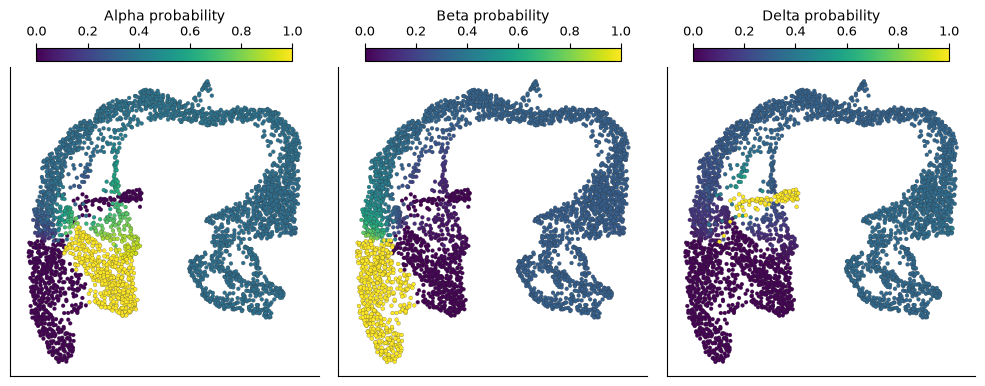

In [8]:
# Save each fate probability in the matching cell order.
for index, label in enumerate(fate.sink_labels):
    # Save the values in cell metadata using the stated selection.
    ds.cells.insert(
        f"fate_prob_{sink_names[int(label)]}",
        fate.values[:, index],
        key="I",
        overwrite=True,
    )

# Compare the three fate probabilities on a shared zero-to-one scale.
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by=[
        CellField(
            f"fate_prob_{name}", kind="continuous", label=f"{name} probability"
        )
        for name in candidate_fates
    ],
    n_columns=3,
    color_scale=ColorScale(scope="shared", vmin=0, vmax=1),
    sort_values=True,
)